# EIP-8038 State Access Params Analysis

Analyze the estimated new gas values from `new_gas_all_params.csv` (benchmarkoor, 2026-03-01 to 2026-03-12).

**Questions:**
1. How do different tests and variants (cache strategy, account mode, existing slots) impact the new gas for each parameter?
2. Do different clients show different behavior across tests and variants?

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 13}
)

repo_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

## 1. Process data and do quick EDA

In [3]:
# Load data
data_dir = os.path.join(
    repo_dir,
    "reports",
    "eip-8038",
    "runtime_estimation",
    "2026-03-01_2026-03-12_benchmarkoor",
)
df = pd.read_csv(os.path.join(data_dir, "new_gas_all_params.csv"))

# Fill NaN variants with descriptive labels
df["cache_strategy"] = df["cache_strategy"].fillna("N/A")
df["account_mode"] = df["account_mode"].fillna("N/A")
df["existing_slots"] = (
    df["existing_slots"]
    .map({True: "existing", False: "new", None: "N/A"})
    .fillna("N/A")
)

# Short test names and params for readability
df["test_short"] = (
    df["test_name"].str.replace("test_", "").str.replace("_benchmark", "")
)
df["gas_param_short"] = df["gas_param"].str.replace("GAS_", "")

# Combined variant label
def variant_label(row):
    parts = []
    if row["cache_strategy"] != "N/A":
        parts.append(row["cache_strategy"].replace("CACHE_", "").lower())
    if row["account_mode"] != "N/A":
        parts.append(row["account_mode"].replace("_", " ").lower())
    if row["existing_slots"] != "N/A":
        parts.append(f"slots={row['existing_slots']}")
    return " | ".join(parts) if parts else "default"


df["variant"] = df.apply(variant_label, axis=1)

# Shared references
gas_params = sorted(df["gas_param"].unique())
clients = sorted(df["client_name"].unique())

df.head()

,gas_param,client_name,runtime_ms,pvalue,conf_int_low,conf_int_high,test_name,opcode,coef,glue_adjustment,cache_strategy,account_mode,existing_slots,new_gas,new_gas_rounded,new_gas_conf_int_low,new_gas_conf_int_high,test_short,gas_param_short,variant
0,GAS_WARM_ACCESS,besu,0.000162,0.0,0.000148,0.000177,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,new,9.729305,10.0,9.0,11.0,storage_sload_same_key,WARM_ACCESS,slots=new
1,GAS_WARM_ACCESS,besu,0.000167,0.0,0.000150,0.000184,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,existing,9.993486,10.0,9.0,12.0,storage_sload_same_key,WARM_ACCESS,slots=existing
2,GAS_WARM_ACCESS,geth,0.000160,0.0,0.000157,0.000162,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,new,9.576748,10.0,10.0,10.0,storage_sload_same_key,WARM_ACCESS,slots=new
3,GAS_WARM_ACCESS,geth,0.000162,0.0,0.000159,0.000164,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,existing,9.706019,10.0,10.0,10.0,storage_sload_same_key,WARM_ACCESS,slots=existing
4,GAS_WARM_ACCESS,nethermind,0.000069,0.0,0.000066,0.000072,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,new,4.120803,5.0,4.0,5.0,storage_sload_same_key,WARM_ACCESS,slots=new


In [4]:
gas_bench_df = pd.read_csv(os.path.join(data_dir, "gas_bench_data.csv"))
gas_bench_df = gas_bench_df[
    (gas_bench_df["token_name"] == "9_39GB_ERC20") | (gas_bench_df["token_name"].isna())
]

In [5]:
glue_opcodes_by_test = pd.read_csv(os.path.join(data_dir, f"glue_opcodes_by_test.csv"))
glue_opcodes_by_test = glue_opcodes_by_test[
    glue_opcodes_by_test["test_opcode"].isin(
        ["DELEGATECALL", "STATICCALL", "CALL", "CALLCODE", "SELFDESTRUCT"]
        + ["BALANCE", "EXTCODESIZE", "EXTCODECOPY", "EXTCODEHASH", "SLOAD", "SSTORE"]
    )
]

In [6]:
# Summary stats per gas_param and client
summary = df.groupby(["gas_param", "client_name"])["new_gas"].agg(
    ["mean", "median", "std", "min", "max", "count"]
)
summary = summary.round(2)
summary

mean   median      std  \
gas_param                      client_name                              
GAS_COLD_ACCOUNT_CODE_ACCESS   besu          238.03    41.24   355.21   
                               geth          143.48   105.43    96.98   
                               nethermind     32.49     8.43    47.95   
                               reth           47.08    22.71    81.98   
GAS_COLD_ACCOUNT_NOCODE_ACCESS besu          373.70   301.92   344.57   
                               geth          110.03    92.84    75.12   
                               nethermind     83.28    62.94    66.62   
                               reth           33.40    37.38    12.22   
GAS_COLD_ACCOUNT_WRITE         besu            0.00     0.00     0.00   
                               geth            0.00     0.00     0.00   
                               nethermind      6.08     0.00    13.87   
                               reth            0.00     0.00     0.00   
GAS_COLD_STORAGE_ACCESS        besu         2344.41  2344.41  1775.97   
                               geth         1179.92  1179.92    14.24   
                               nethermind    714.89   714.89   633.80   
                               reth         2777.34  2777.34   236.53   
GAS_WARM_ACCESS                besu          137.82     0.00   512.89   
                               geth           65.61    33.18   112.75   
                               nethermind     50.08    16.54    96.75   
                               reth           14.94     0.00    29.65   

                                                min      max  count  
gas_param                      client_name                           
GAS_COLD_ACCOUNT_CODE_ACCESS   besu            0.00  1150.99     16  
                               geth           31.54   329.90     16  
                               nethermind      0.00   167.38     16  
                               reth            0.00   286.50     16  
GAS_COLD_ACCOUNT_NOCODE_ACCESS besu            0.00  1150.99     13  
                               geth           31.54   258.17     13  
                               nethermind     16.86   206.94     13  
                               reth            5.97    45.48     13  
GAS_COLD_ACCOUNT_WRITE         besu            0.00     0.00      8  
                               geth            0.00     0.00      8  
                               nethermind      0.00    39.46      8  
                               reth            0.00     0.00      8  
GAS_COLD_STORAGE_ACCESS        besu         1088.61  3600.21      2  
                               geth         1169.86  1189.99      2  
                               nethermind    266.73  1163.05      2  
                               reth         2610.09  2944.59      2  
GAS_WARM_ACCESS                besu            0.00  3731.90     55  
                               geth            0.00   573.46     55  
                               nethermind      0.00   614.54     55  
                               reth            0.00   175.83     55

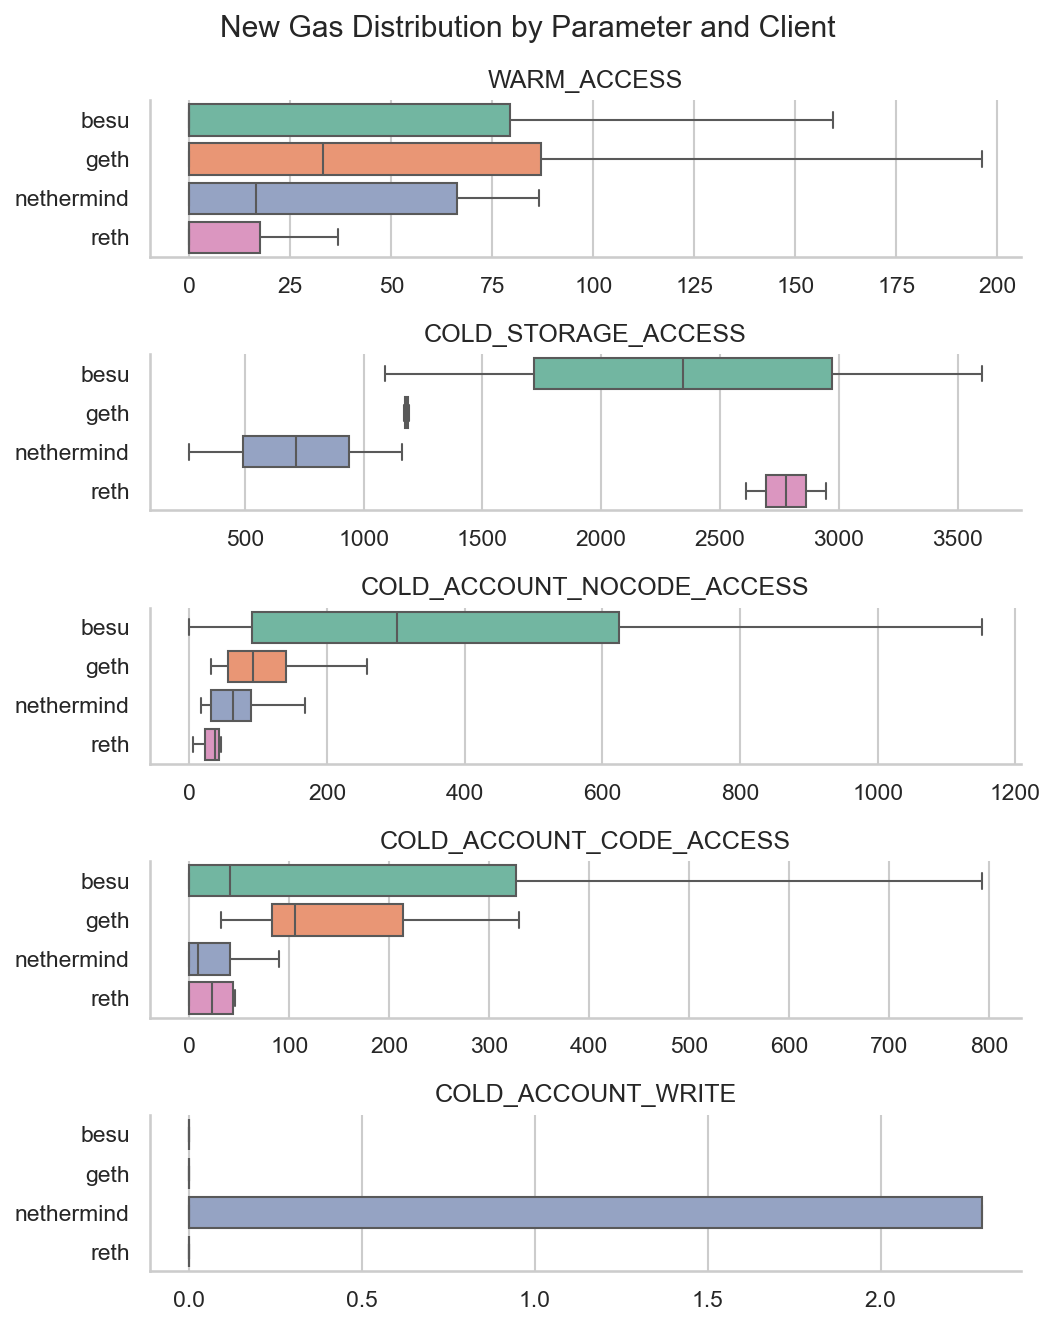

In [7]:
# Box plot: new_gas distribution per gas_param, colored by client
g = sns.catplot(
    data=df,
    y="client_name",
    x="new_gas",
    hue="client_name",
    row="gas_param_short",
    kind="box",
    order=clients,
    showfliers=False,
    height=1.8,
    aspect=4,
    sharex=False,
)
g.set_titles("{row_name}")
g.set_xlabels("")
g.set_ylabels("")
g.figure.suptitle("New Gas Distribution by Parameter and Client")
plt.tight_layout()
plt.show()

## 2. Impact of Test and Variants on Each Gas Parameter

For each gas parameter, break down new gas by test, cache strategy, account mode, and existing slots.

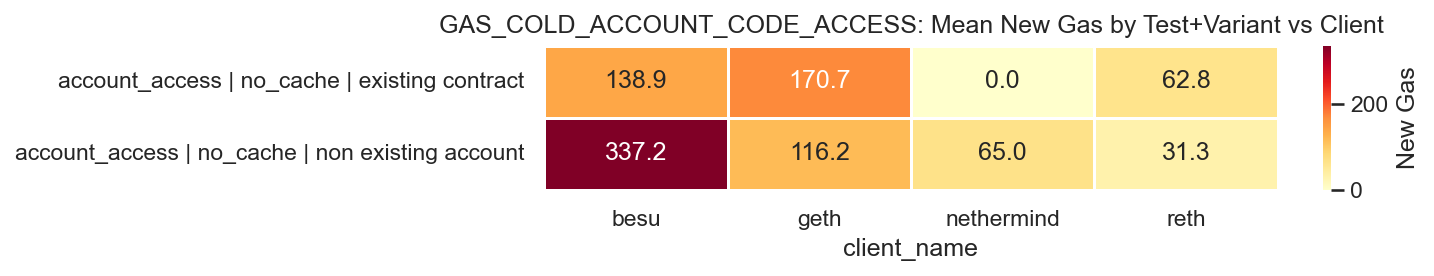

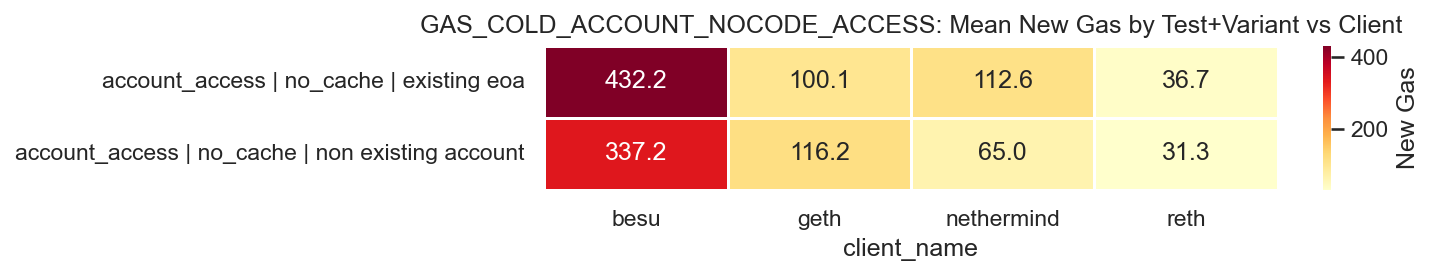

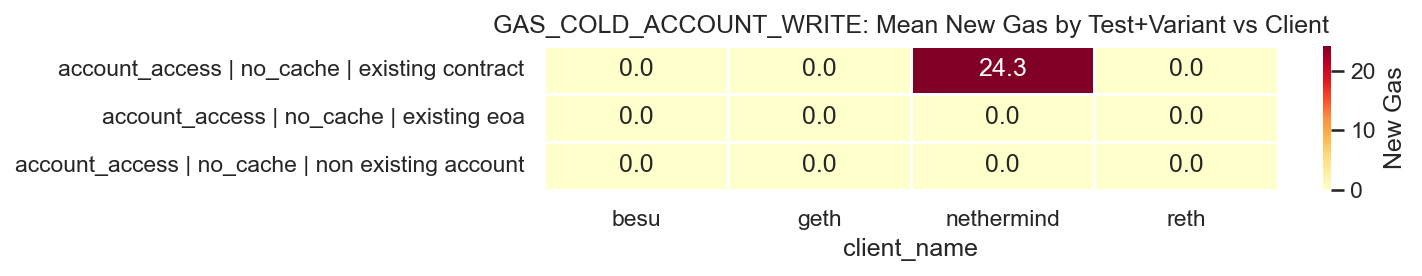

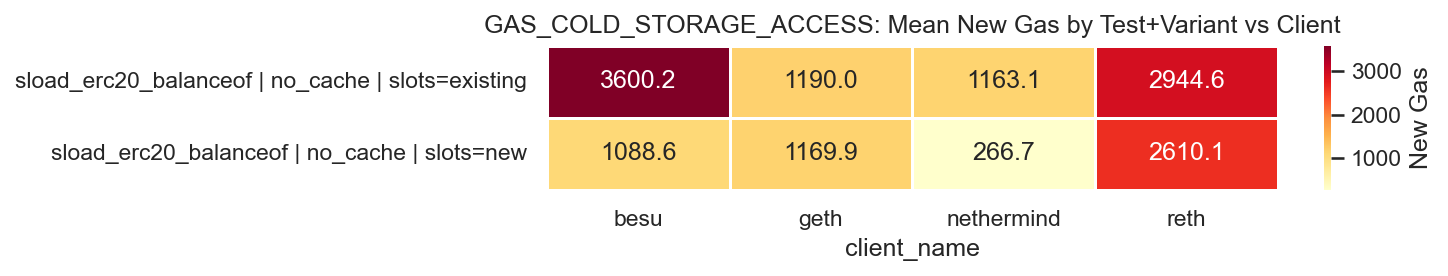

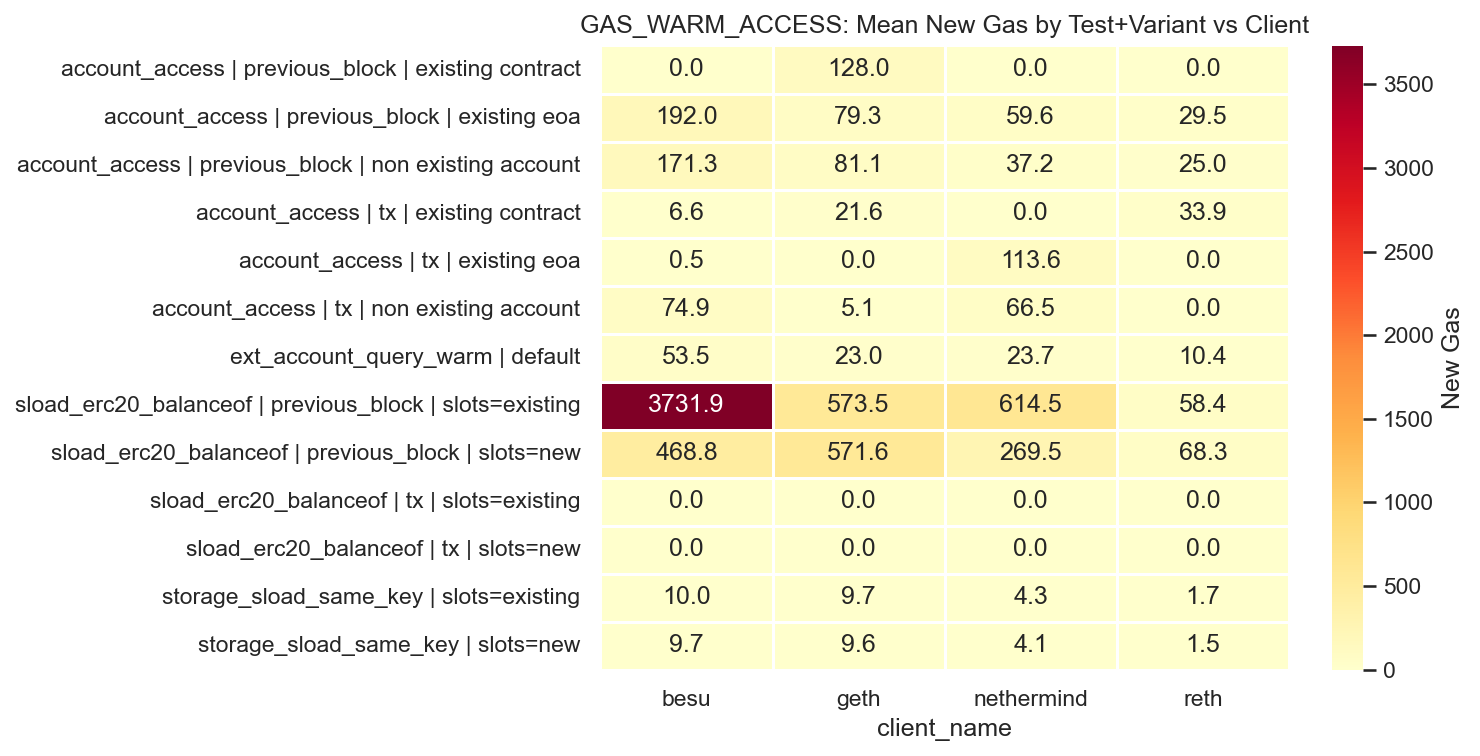

In [8]:
# Heatmap: mean new_gas by test+variant vs client, for each gas param
for gp in gas_params:
    gp_df = df[df["gas_param"] == gp].copy()
    gp_df["test_variant"] = gp_df["test_short"] + " | " + gp_df["variant"]

    pivot = gp_df.pivot_table(
        index="test_variant", columns="client_name", values="new_gas", aggfunc="mean"
    )
    pivot = pivot[clients]

    if pivot.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, max(2, len(pivot) * 0.4)))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "New Gas"},
    )
    ax.set_title(f"{gp}: Mean New Gas by Test+Variant vs Client", fontsize=12)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 3. Impact of Cache Strategy

How does cache strategy (TX, PREVIOUS_BLOCK) affect GAS_WARM_ACCESS?

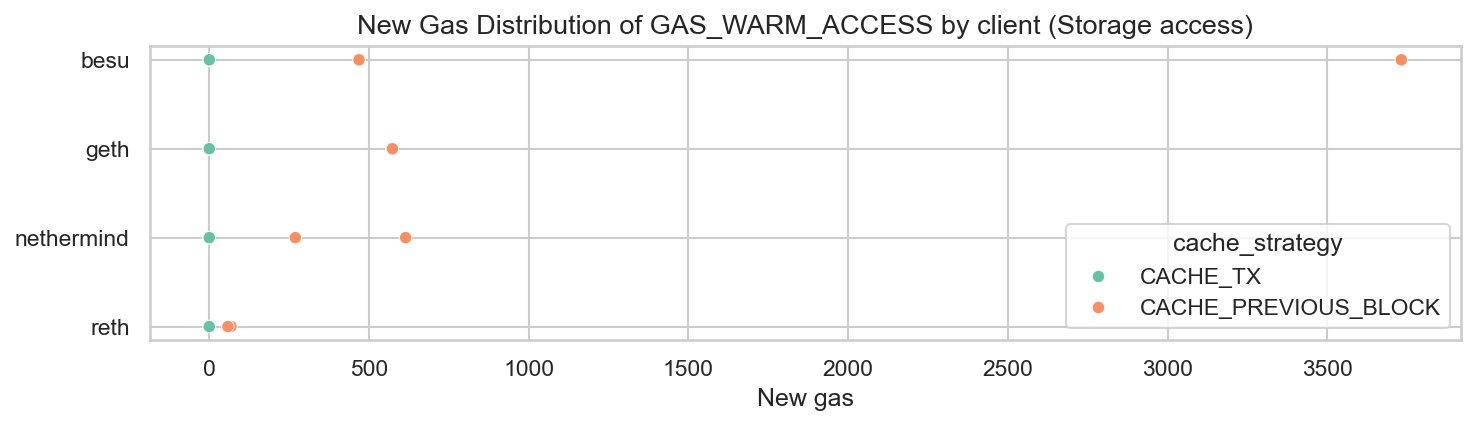

In [9]:
temp_df = df[
    (df["cache_strategy"] != "N/A")
    & (df["gas_param"] == "GAS_WARM_ACCESS")
    & (df["opcode"].isin(["SSTORE", "SLOAD"]))
]

plt.figure(figsize=(10, 3))
sns.scatterplot(
    data=temp_df, y="client_name", x="new_gas", hue="cache_strategy",
)
plt.xlabel("New gas")
plt.ylabel("")
plt.title("New Gas Distribution of GAS_WARM_ACCESS by client (Storage access)")
plt.tight_layout()
plt.show()

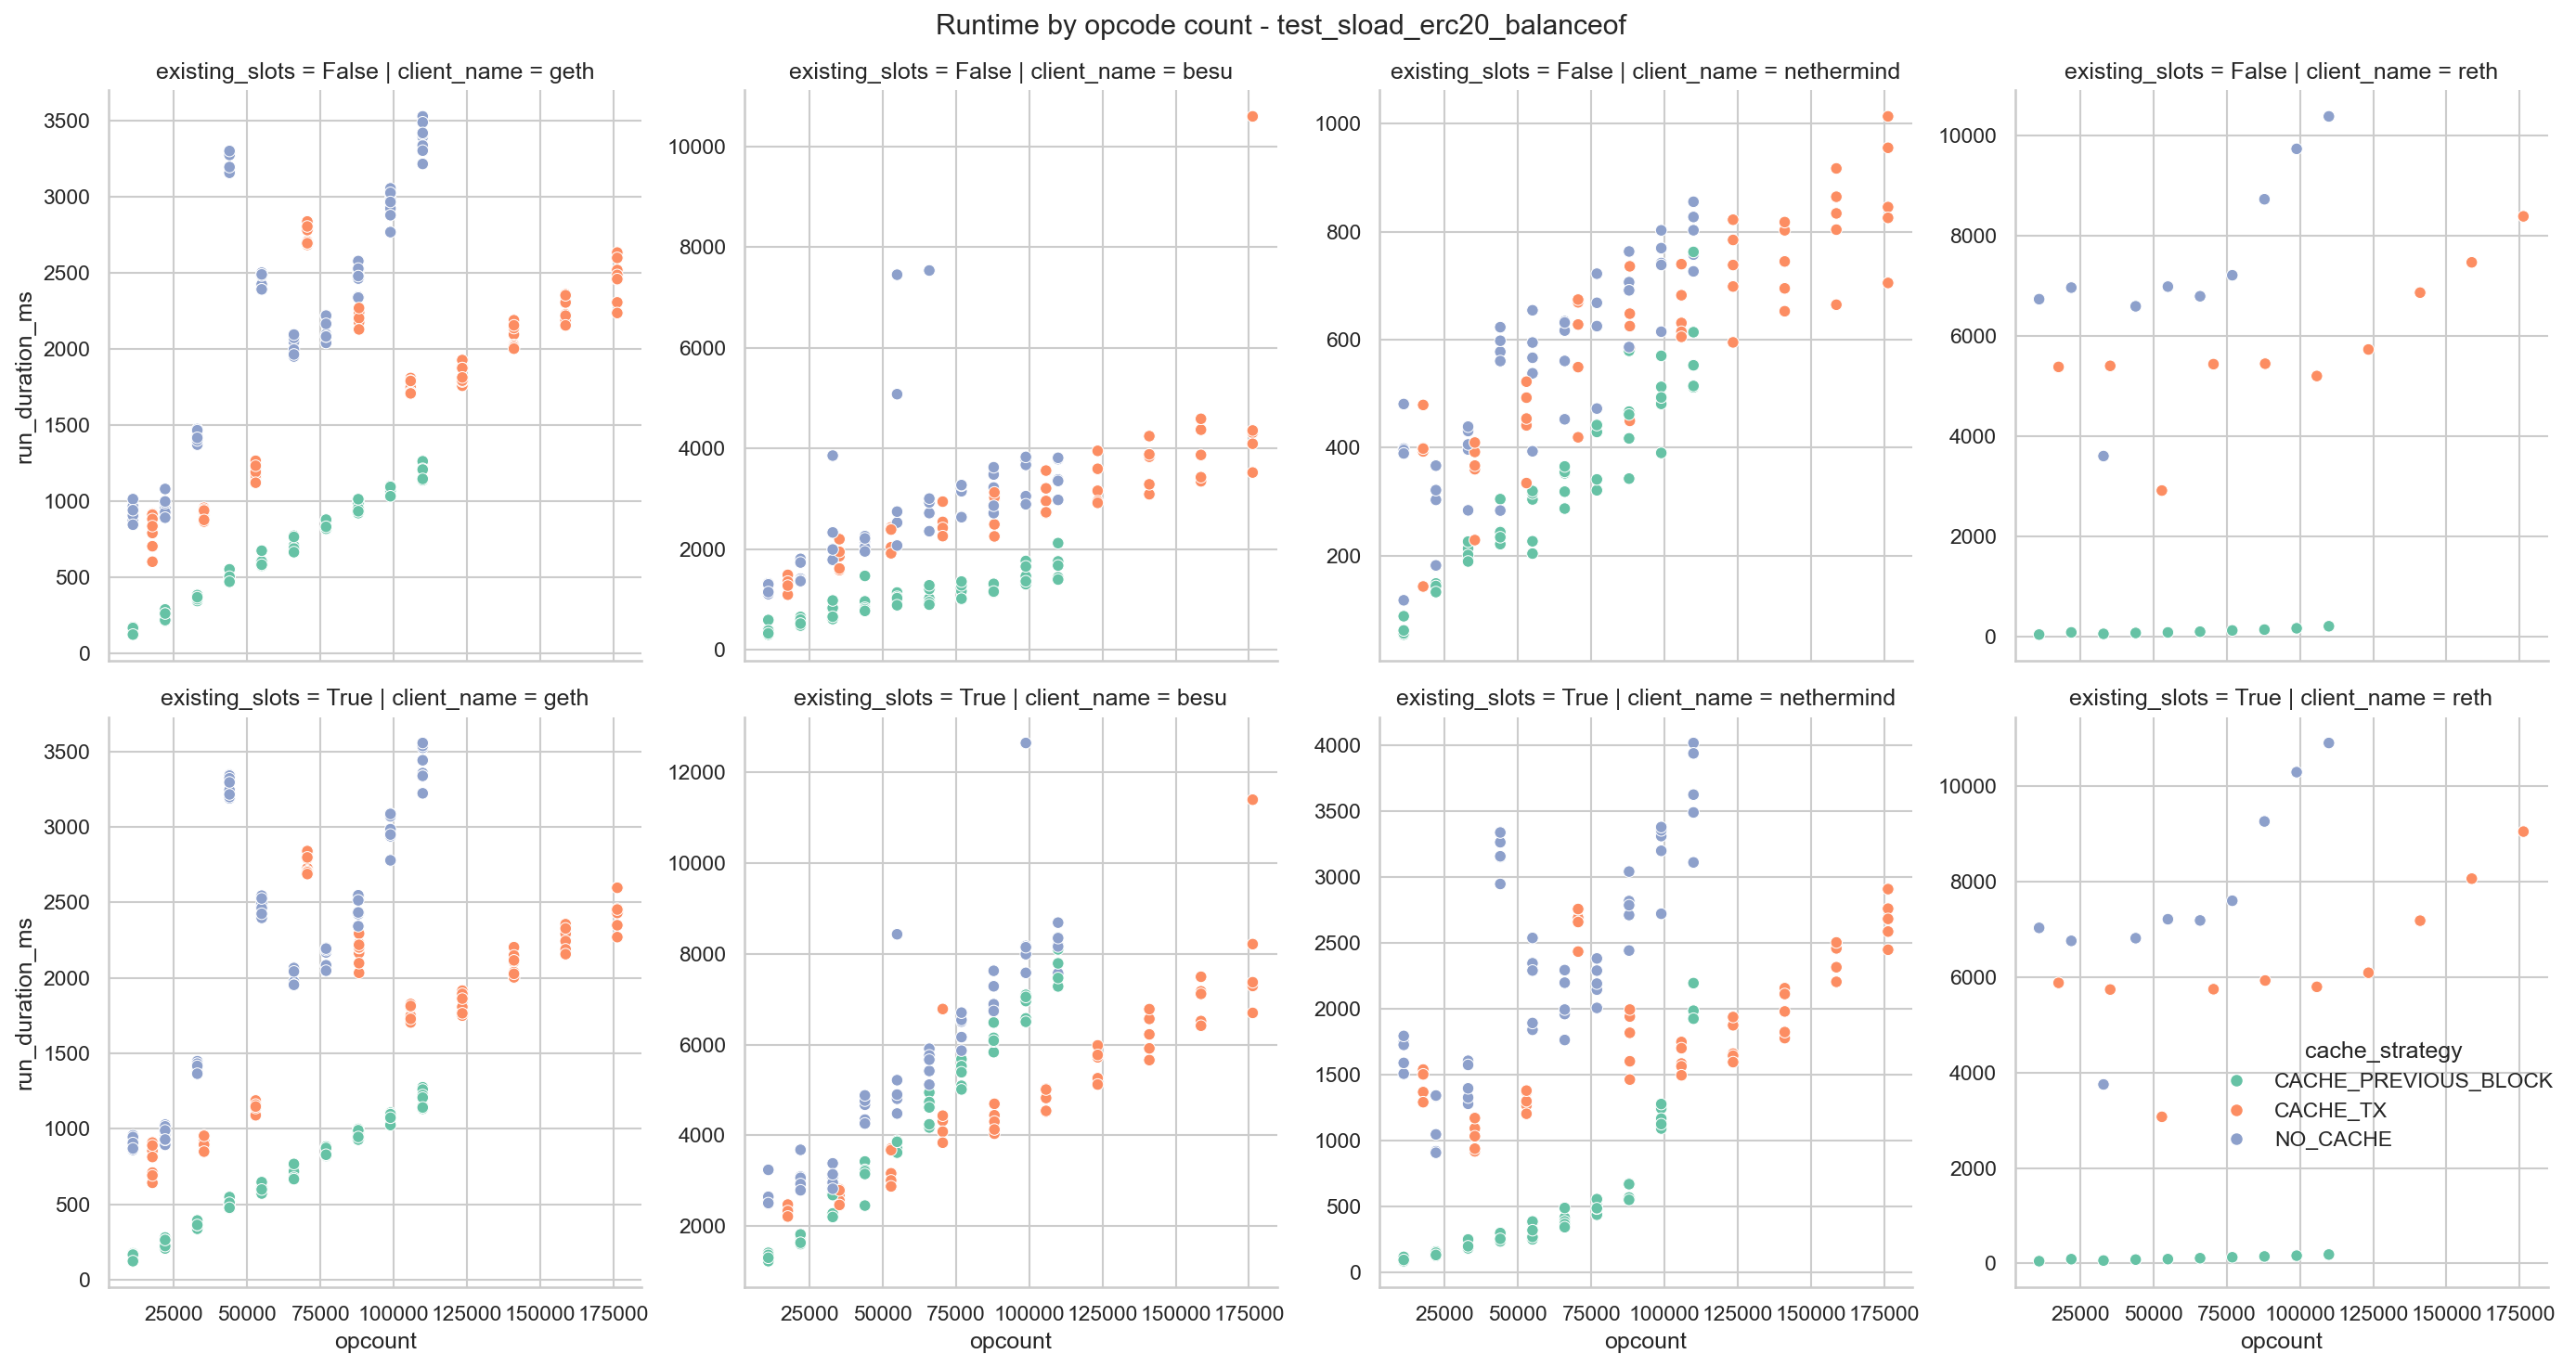

In [10]:
sload_df = gas_bench_df[
    (gas_bench_df["test_opcode"] == "SLOAD")
    & (gas_bench_df["test_name"] == "test_sload_erc20_balanceof")
]

g = sns.relplot(
    data=sload_df,
    x="opcount",
    y="run_duration_ms",
    hue="cache_strategy",
    col="client_name",
    row="existing_slots",
    facet_kws={"sharey": False},
    aspect=0.8,
)
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_sload_erc20_balanceof")
plt.tight_layout()
plt.show()

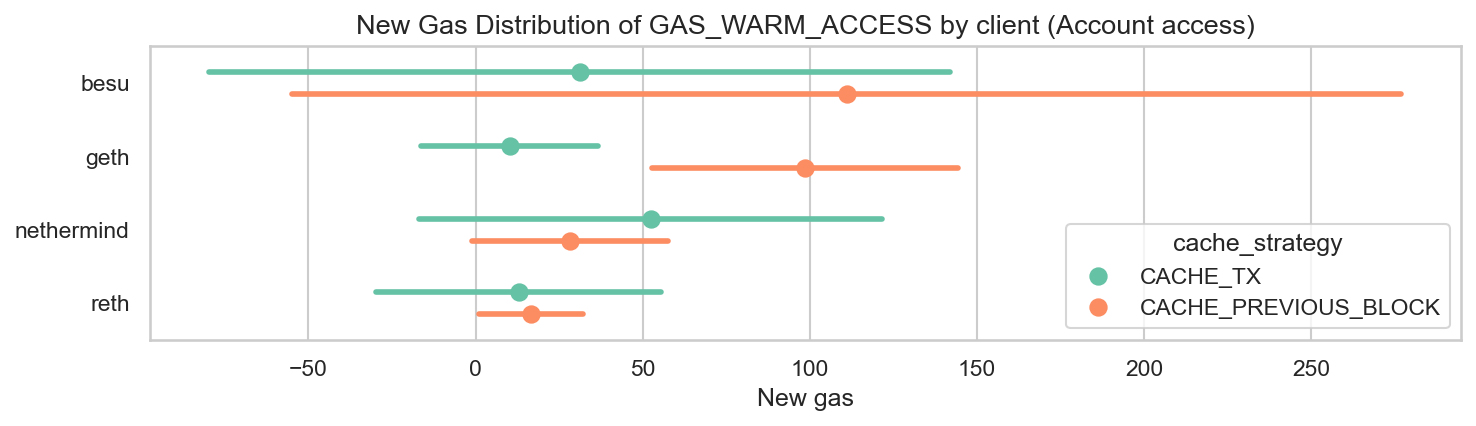

In [11]:
temp_df = df[
    (df["cache_strategy"] != "N/A")
    & (df["gas_param"] == "GAS_WARM_ACCESS")
    & (~df["opcode"].isin(["SSTORE", "SLOAD"]))
]

plt.figure(figsize=(10, 3))
sns.pointplot(
    data=temp_df, y="client_name", x="new_gas", hue="cache_strategy", errorbar="sd", join=False, dodge=0.3
)
plt.xlabel("New gas")
plt.ylabel("")
plt.title("New Gas Distribution of GAS_WARM_ACCESS by client (Account access)")
plt.tight_layout()
plt.show()

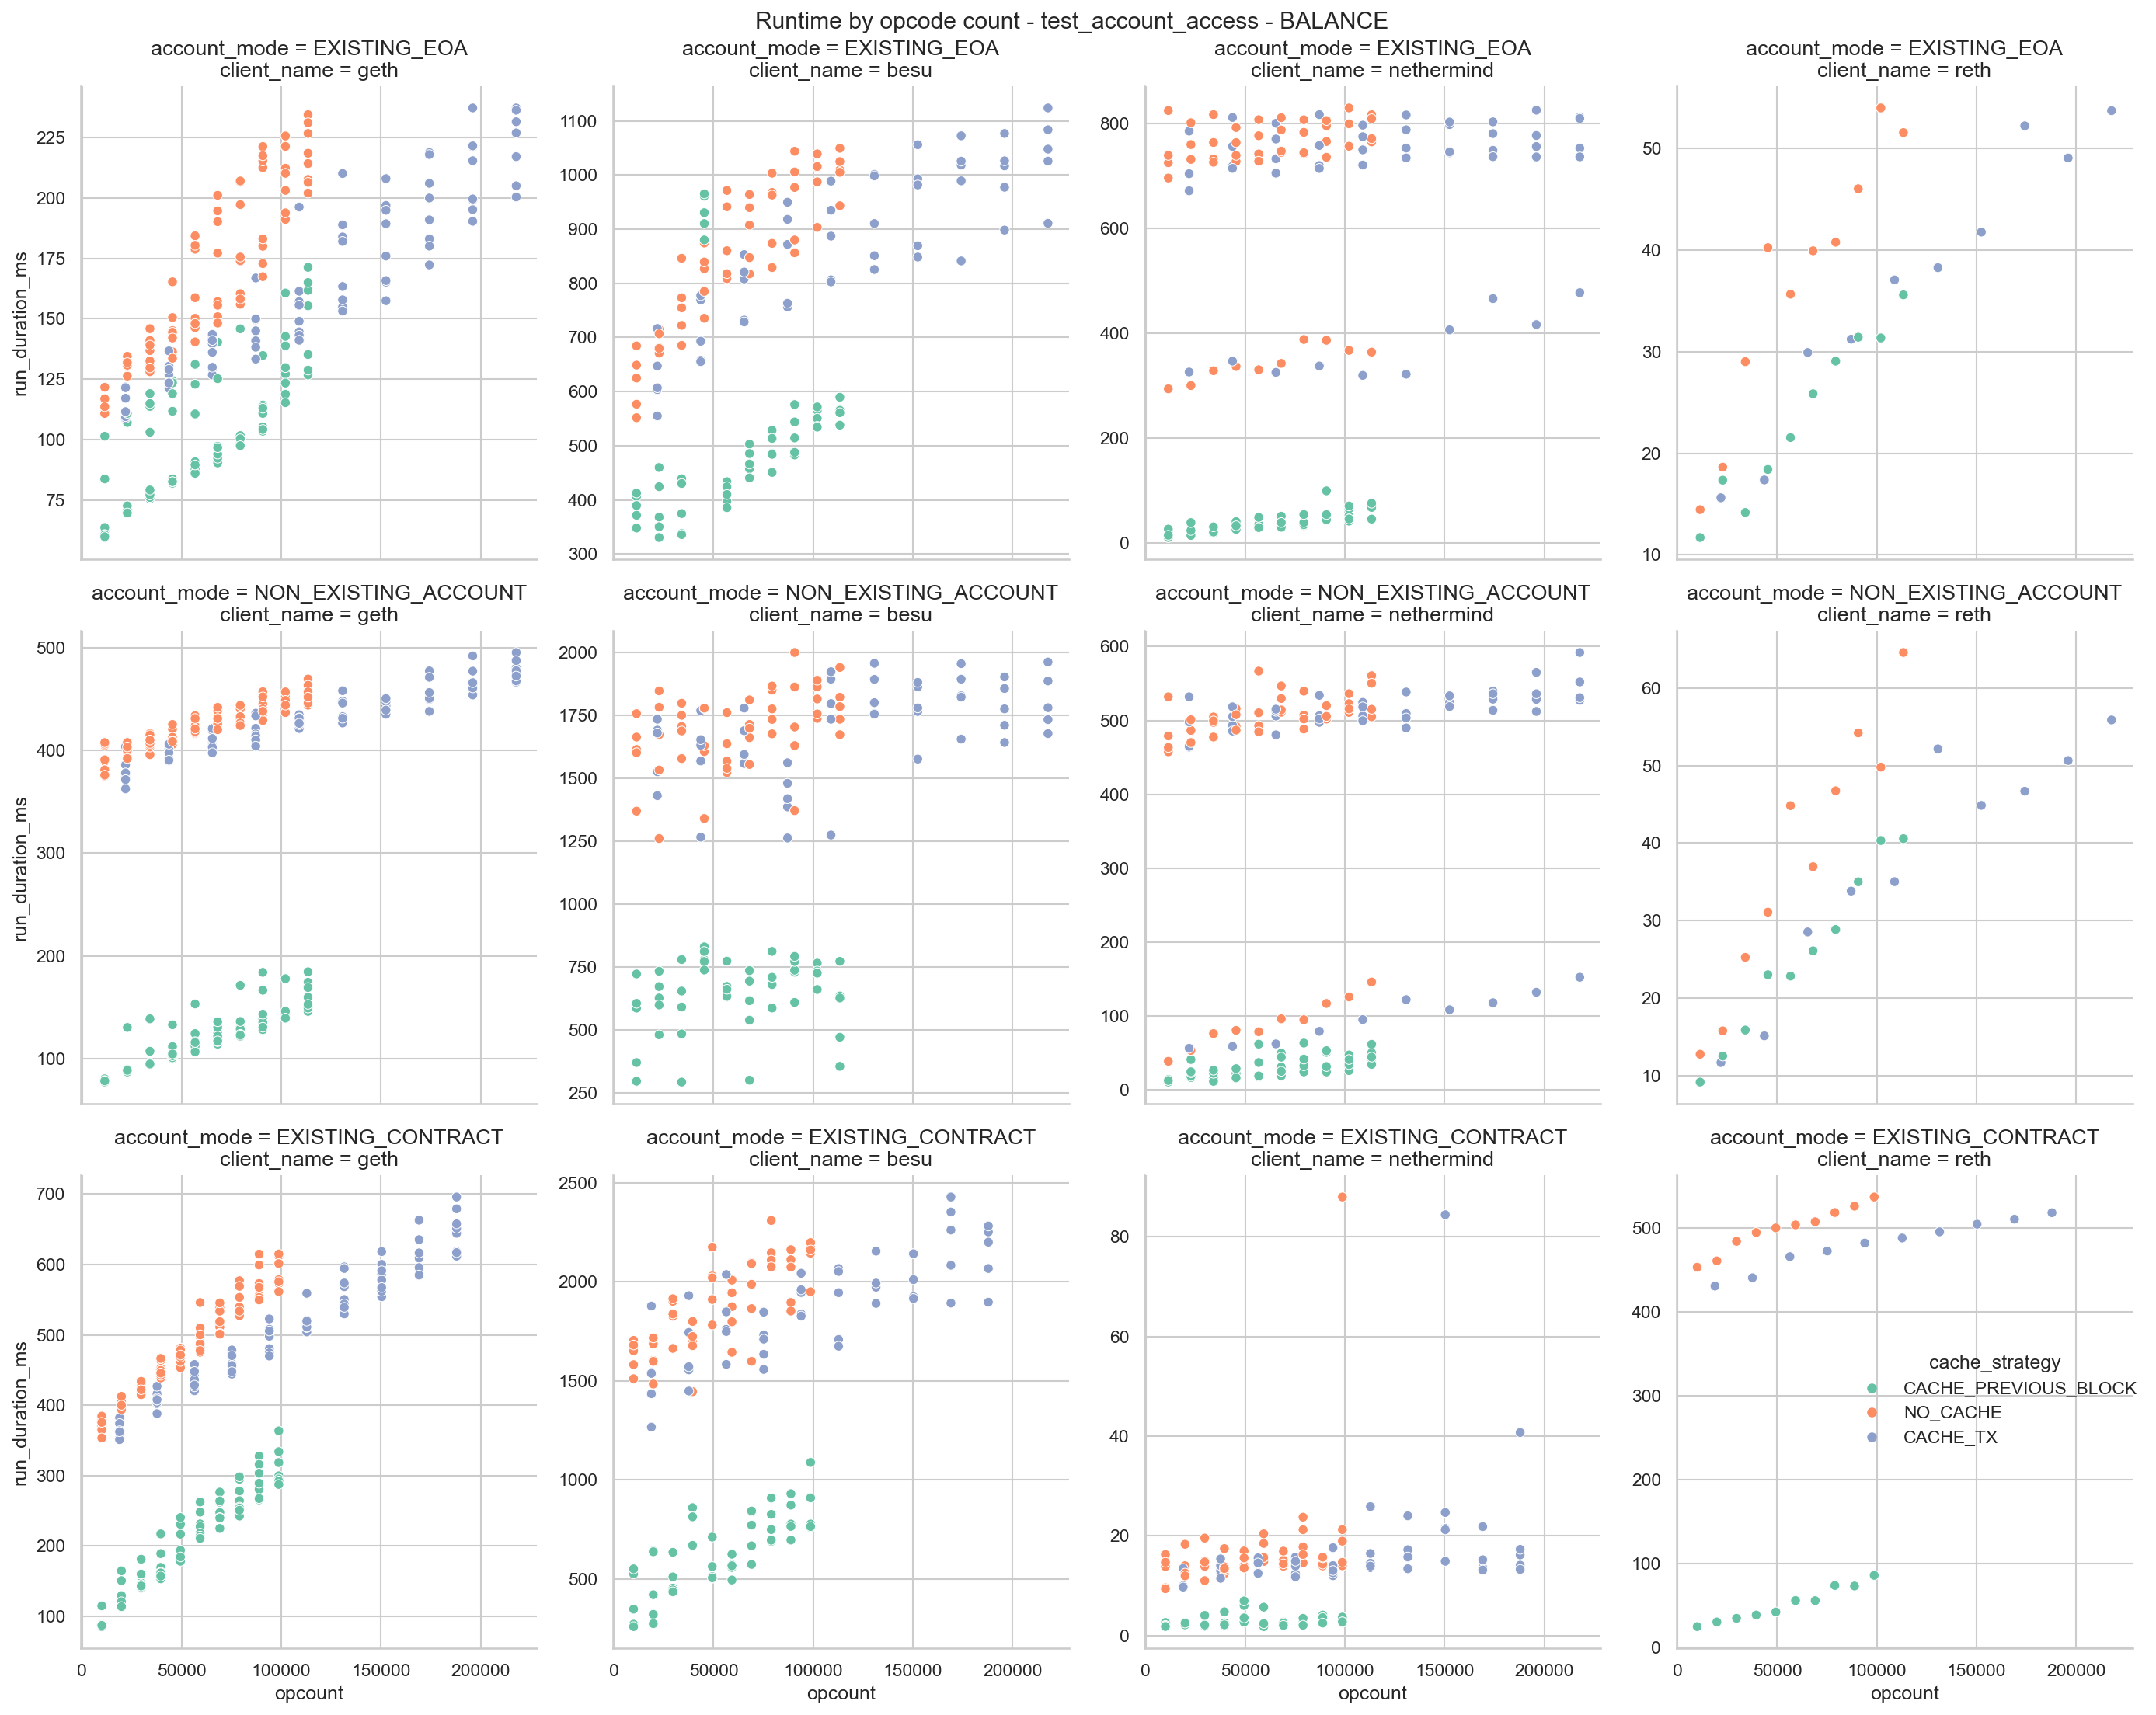

In [12]:
temp_df = gas_bench_df[
    (gas_bench_df["test_opcode"] == "BALANCE")
    & (gas_bench_df["test_name"] == "test_account_access")
]

g = sns.relplot(
    data=temp_df,
    x="opcount",
    y="run_duration_ms",
    hue="cache_strategy",
    col="client_name",
    row="account_mode",
    facet_kws={"sharey": False},
    aspect=0.8,
)
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.replace(" | ", "\n"))
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_account_access - BALANCE")
plt.tight_layout()
plt.show()

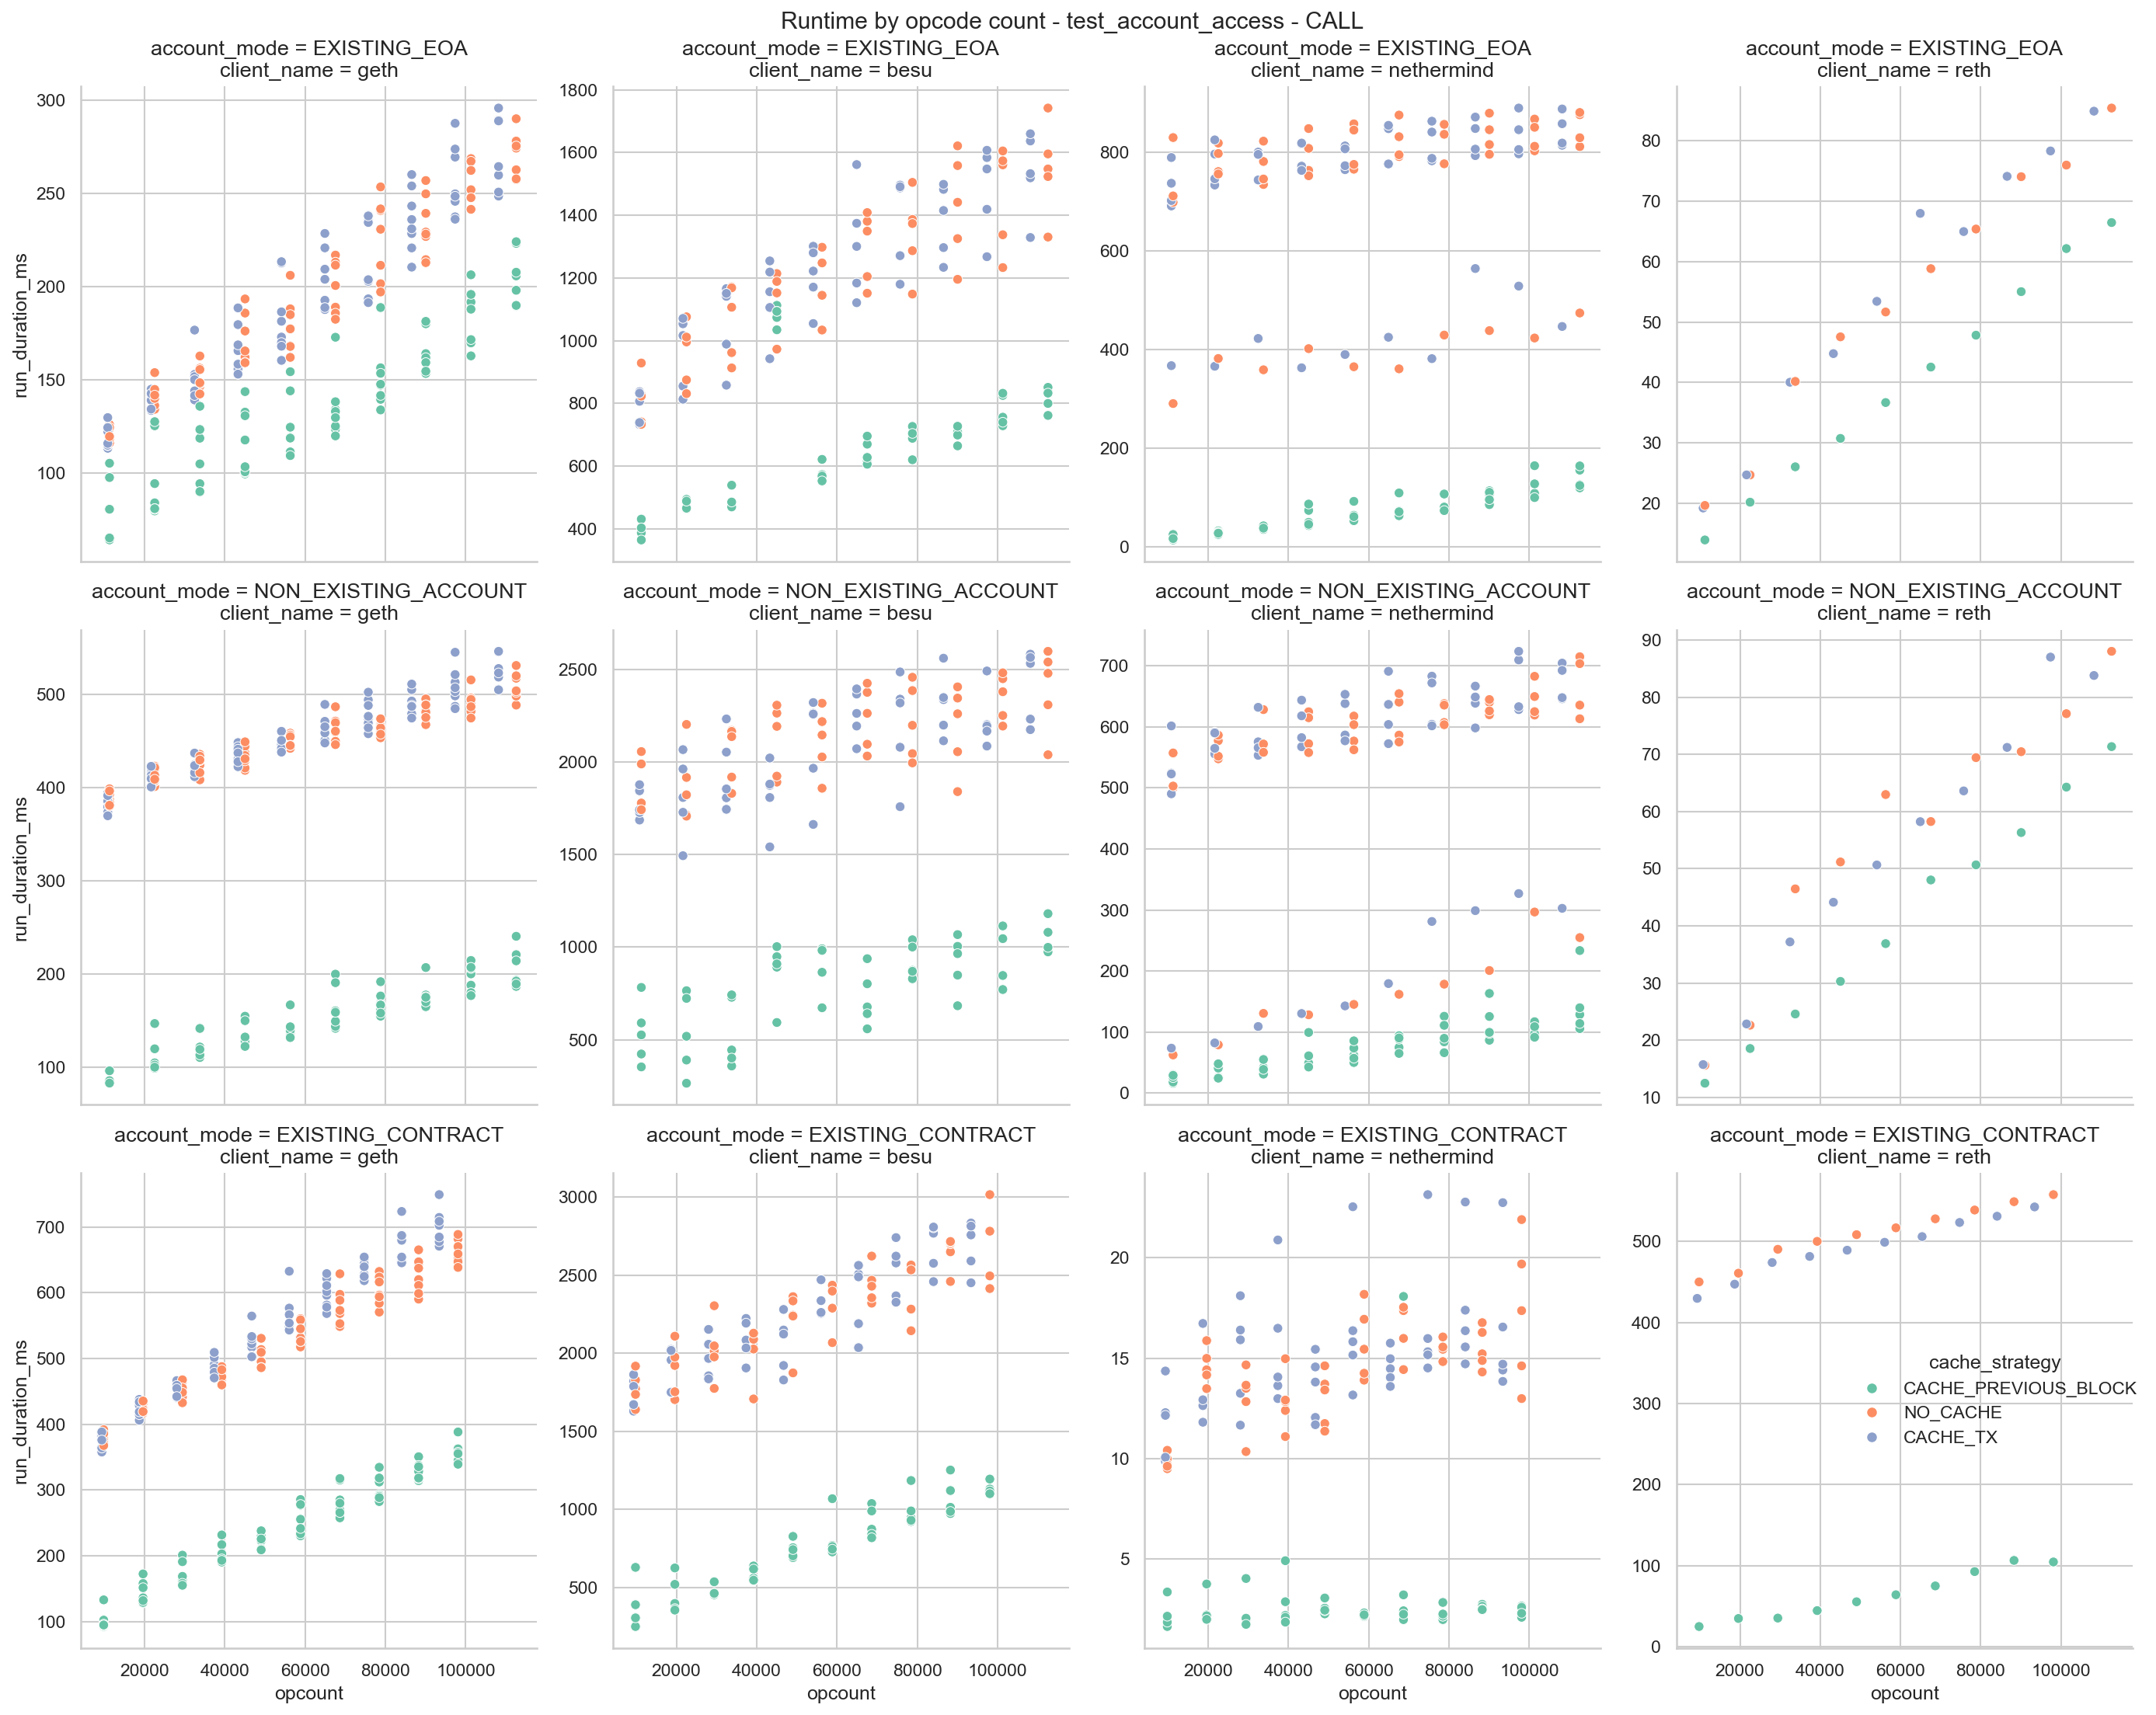

In [13]:
temp_df = gas_bench_df[
    (gas_bench_df["test_opcode"] == "CALL")
    & (gas_bench_df["test_params"] == "update_0")
    & (gas_bench_df["test_name"] == "test_account_access")
]

g = sns.relplot(
    data=temp_df,
    x="opcount",
    y="run_duration_ms",
    hue="cache_strategy",
    col="client_name",
    row="account_mode",
    facet_kws={"sharey": False},
    aspect=0.8,
)
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.replace(" | ", "\n"))
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_account_access - CALL")
plt.tight_layout()
plt.show()

The new gas for `CACHE_PREVIOUS_BLOCK` is almost always zero. This is due to the fact that runtime for `NO_CACHE` is higher or equal to `CACHE_TX`, which is weird. The variant `CACHE_TX` should have an additional warm `SLOAD` or `BALANCE` and this should always take more time to run.

Let's check the glue opcode ratios:

In [14]:
glue_opcodes_by_test[glue_opcodes_by_test["glue_opcode"] == "BALANCE"][
    ["test_opcode", "cache_strategy", "account_mode", "ratio"]
]

,test_opcode,cache_strategy,account_mode,ratio
186,CALL,CACHE_TX,EXISTING_CONTRACT,1.000232
197,CALL,CACHE_TX,EXISTING_EOA,1.000000
208,CALL,CACHE_TX,NON_EXISTING_ACCOUNT,1.000000
318,CALLCODE,CACHE_TX,EXISTING_CONTRACT,1.000280
329,CALLCODE,CACHE_TX,EXISTING_EOA,1.000000
340,CALLCODE,CACHE_TX,NON_EXISTING_ACCOUNT,1.000000
446,DELEGATECALL,CACHE_TX,EXISTING_CONTRACT,1.000214
458,DELEGATECALL,CACHE_TX,EXISTING_EOA,1.000000
470,DELEGATECALL,CACHE_TX,NON_EXISTING_ACCOUNT,1.000000
562,EXTCODECOPY,CACHE_TX,EXISTING_CONTRACT,1.000000


Ratios look good for test_account_query. How about the storage tests?

In [15]:
glue_opcodes_by_test[glue_opcodes_by_test["glue_opcode"] == "SLOAD"][
    ["test_name", "cache_strategy", "existing_slots", "ratio"]
]

,test_name,cache_strategy,existing_slots,ratio
1860,test_sstore_erc20_mint,CACHE_PREVIOUS_BLOCK,False,1.000000
1901,test_sstore_erc20_mint,CACHE_PREVIOUS_BLOCK,True,1.000000
1943,test_sstore_erc20_mint,CACHE_TX,False,1.500026
1986,test_sstore_erc20_mint,CACHE_TX,True,1.500086
2028,test_sstore_erc20_mint,NO_CACHE,False,1.000000
2069,test_sstore_erc20_mint,NO_CACHE,True,1.000000


In [16]:
sload_df[sload_df["block_limit_million"] == 300][
    ["test_name", "cache_strategy", "existing_slots", "opcount"]
].drop_duplicates()

,test_name,cache_strategy,existing_slots,opcount
232642,test_sload_erc20_balanceof,CACHE_PREVIOUS_BLOCK,False,109862.0
232645,test_sload_erc20_balanceof,CACHE_PREVIOUS_BLOCK,True,109862.0
232887,test_sload_erc20_balanceof,CACHE_TX,False,176256.0
232893,test_sload_erc20_balanceof,CACHE_TX,True,176273.0
232956,test_sload_erc20_balanceof,NO_CACHE,True,109862.0
232959,test_sload_erc20_balanceof,NO_CACHE,False,109862.0


We know we have a issue with `test_sstore_erc20_mint`, which is being fixed. However, `test_sload_erc20_balanceof` also seems to have strange opcode counts. The ratio between the `SLOAD` opcode counts of `CACHE_TX` and the other variants is 0.62, when we would expect to see 0.5. We will need to investigate this further.

## 4. Impact of Account Mode

How do existing contracts vs EOAs vs non-existing accounts affect cold access gas?

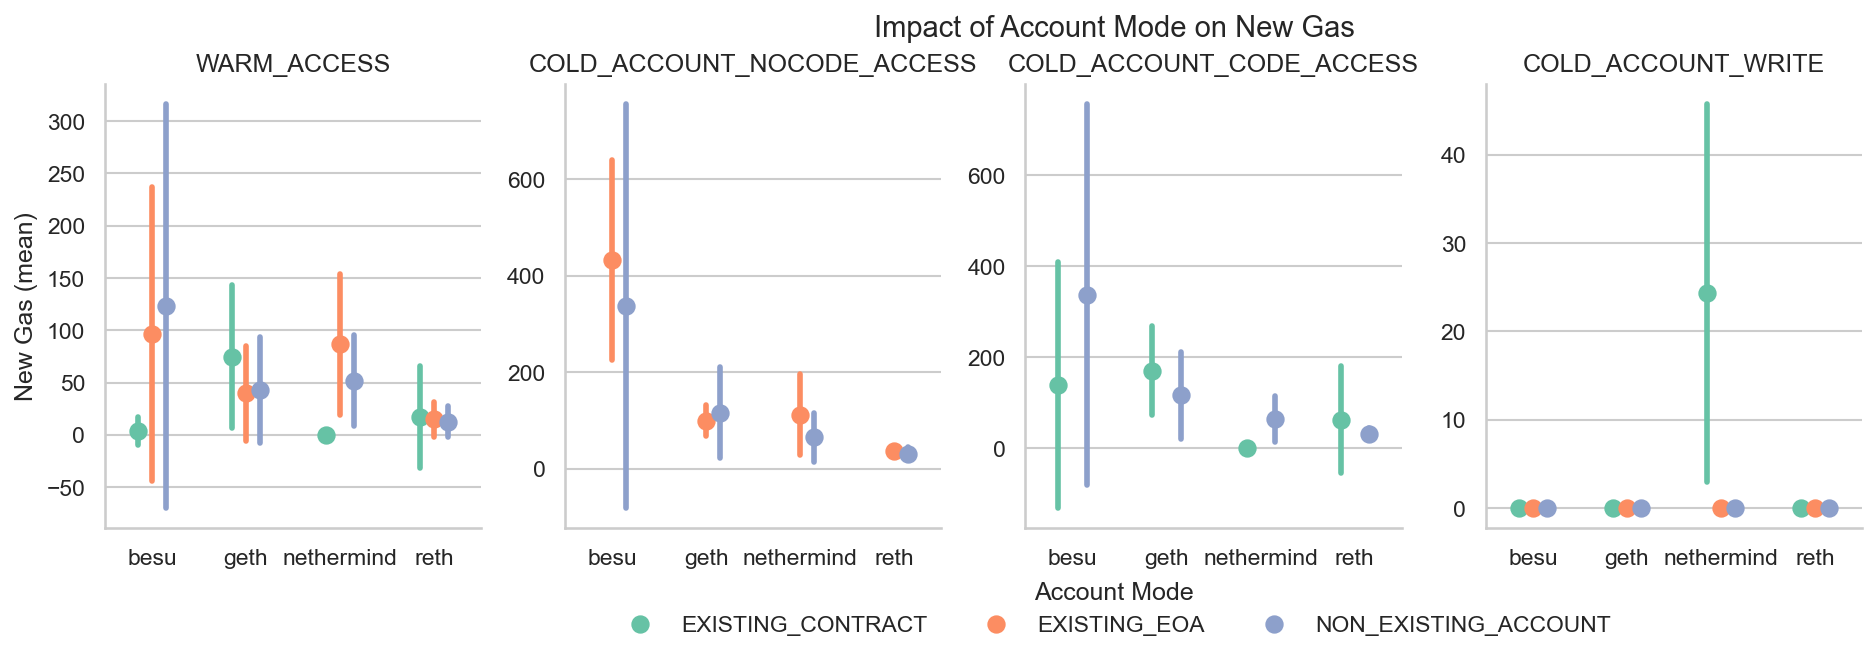

In [17]:
# Filter to rows with actual account mode values
acct_df = df[(df["account_mode"] != "N/A")]
acct_df["gas_param_short"] = acct_df["gas_param"].str.replace("GAS_", "")

g = sns.catplot(
    data=acct_df,
    x="client_name",
    y="new_gas",
    hue="account_mode",
    col="gas_param_short",
    kind="point",
    order=clients,
    errorbar="sd",
    height=4,
    aspect=0.8,
    sharey=False,
    join=False,
    dodge=0.3
)
g.set_titles("{col_name}", fontsize=11)
g.set_xlabels("")
g.set_ylabels("New Gas (mean)")
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, title="Account Mode")
g.figure.suptitle("Impact of Account Mode on New Gas", fontsize=14, y=1.02)

plt.show()

As expected, different clients show different behaviors on the worst case for the account mode.

## 5. Impact of Existing Slots

Does accessing existing vs new storage slots change the gas estimation?

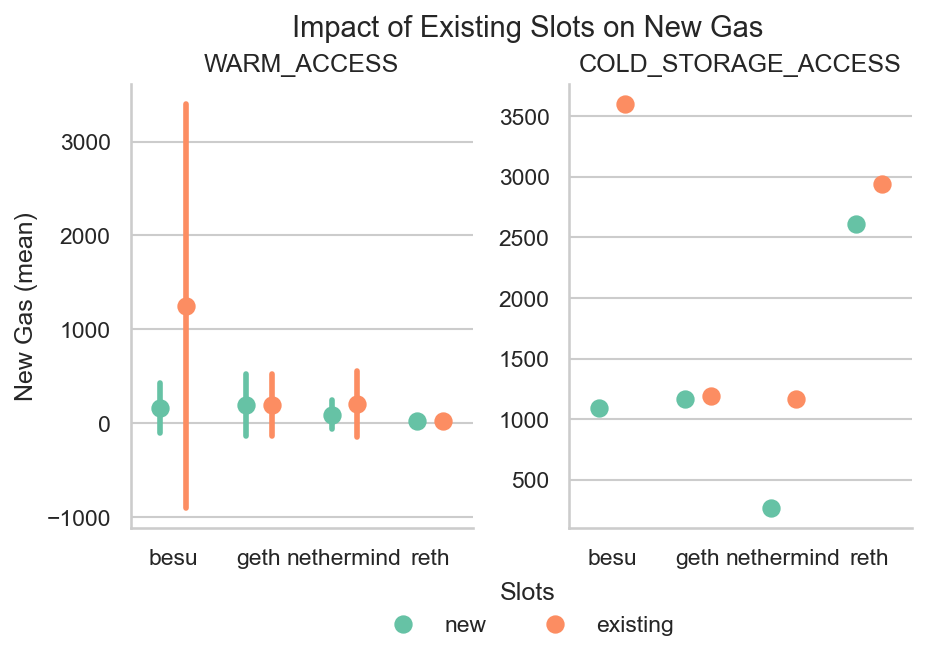

In [18]:
# Filter to rows with actual existing_slots values
slots_df = df[df["existing_slots"] != "N/A"].copy()
slots_df["gas_param_short"] = slots_df["gas_param"].str.replace("GAS_", "")

g = sns.catplot(
    data=slots_df,
    x="client_name",
    y="new_gas",
    hue="existing_slots",
    col="gas_param_short",
    kind="point",
    order=clients,
    errorbar="sd",
    height=4,
    aspect=0.8,
    sharey=False,
    join=False,
    dodge=0.3
)
g.set_titles("{col_name}", fontsize=11)
g.set_xlabels("")
g.set_ylabels("New Gas (mean)")
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, title="Slots")
g.figure.suptitle("Impact of Existing Slots on New Gas", fontsize=14, y=1.02)
plt.show()

Strangely, for `test_sload_erc20_balanceof`, the existing slot variant always takes longer to run, which is not consistent with our expectation. For instance, we would expect geth to take longer in the non-existing variant.